In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("netflix_titles.csv")


In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape

(8807, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [12]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [13]:
##  remoce rows where data is missing
df = df.dropna(subset=['date_added'])

In [14]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

In [15]:
## convert date format
df['date_added'] = df['date_added'].str.strip()

In [16]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [17]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

In [18]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September


In [19]:
## save clean data
df.to_csv("netflix_cleaned.csv", index=False)

# Missing Values Analysis
This section analyzes missing values present in the Netflix dataset before preprocessing.

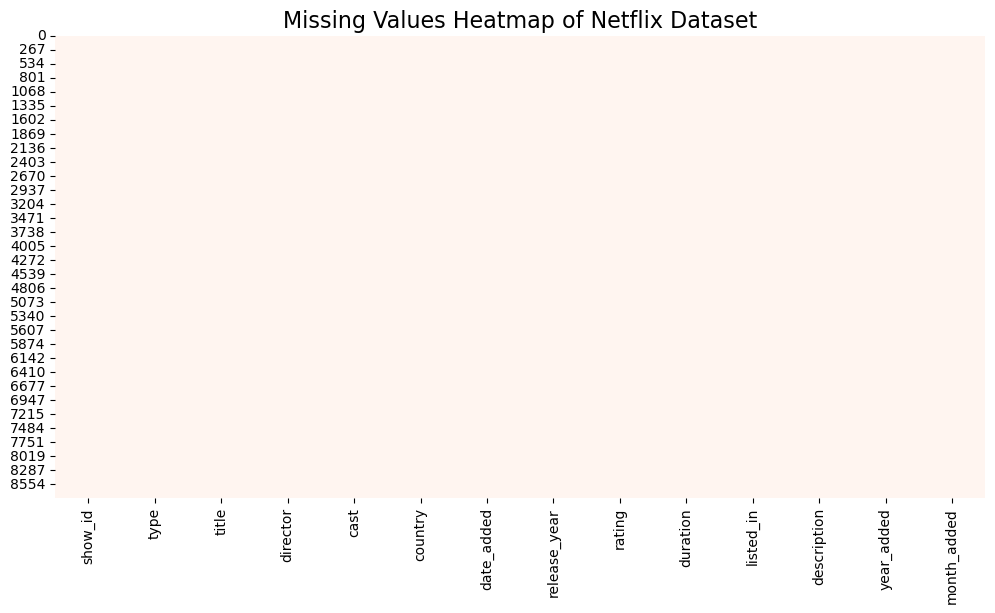

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(12,6))

# Create heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='Reds')

# Title
plt.title('Missing Values Heatmap of Netflix Dataset', fontsize=16)

# Show plot
plt.show()

In [21]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


# WordCloud of Netflix Titles

This visualization represents the most frequently occurring words in Netflix movie and TV show titles.

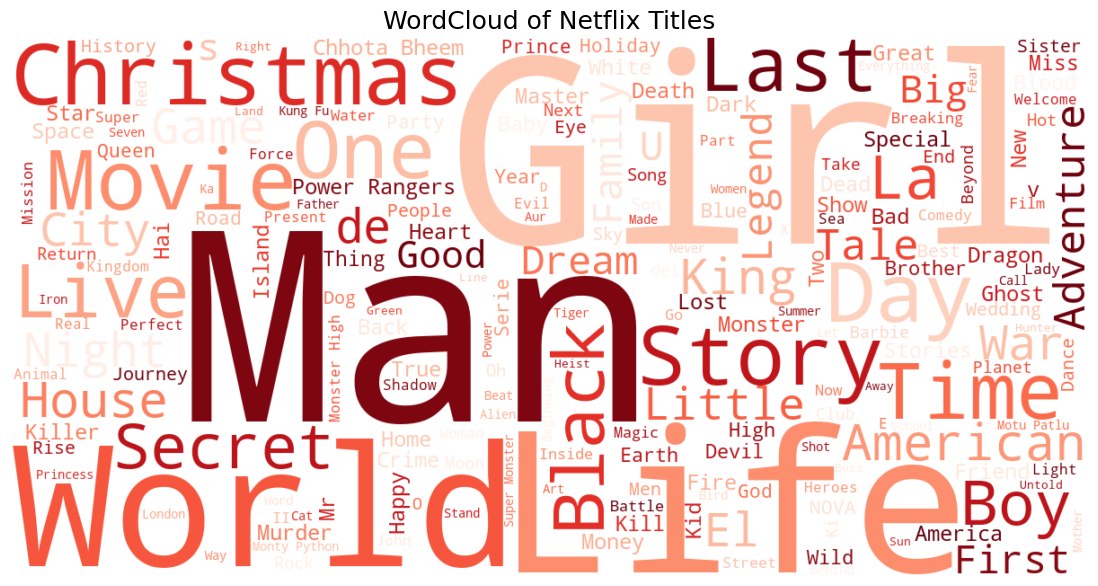

In [28]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine all titles
text = " ".join(title for title in df['title'].dropna())

# Custom stopwords
custom_stopwords = set(STOPWORDS)

# Add words you want to hide
custom_stopwords.update([
    'love'
])

# Create WordCloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Reds',
    stopwords=custom_stopwords
).generate(text)

# Plot
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

# Title
plt.title('WordCloud of Netflix Titles', fontsize=18)

plt.show()

# Distribution of Movie Durations

This graph analyzes the duration distribution of Netflix movies.

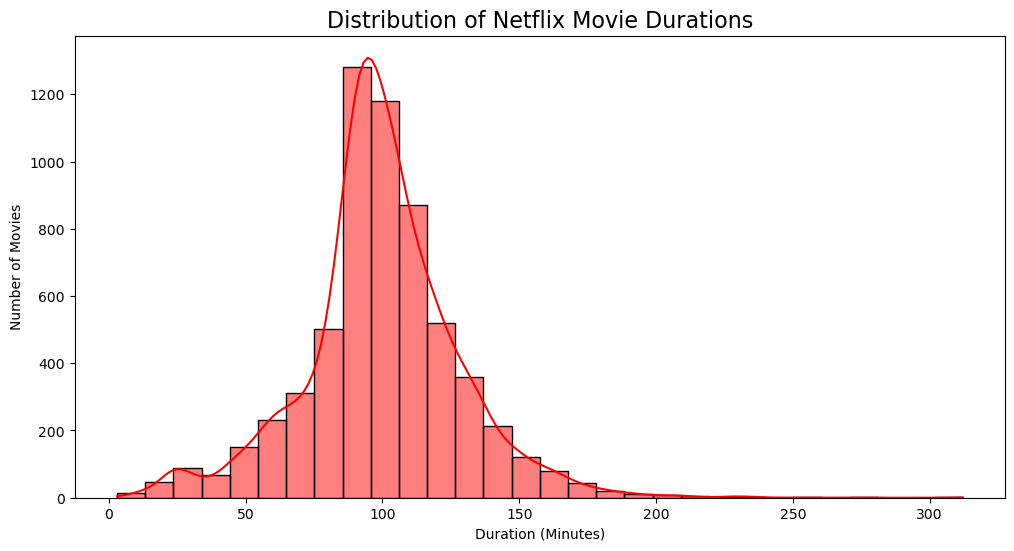

In [23]:
# Filter only movies
movies_df = df[df['type'] == 'Movie'].copy()

# Extract numeric duration
movies_df['duration_int'] = movies_df['duration'].str.extract('(\d+)').astype(float)

# Plot histogram
plt.figure(figsize=(12,6))

sns.histplot(
    movies_df['duration_int'],
    bins=30,
    kde=True,
    color='red'
)

# Labels
plt.title('Distribution of Netflix Movie Durations', fontsize=16)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()

# Monthly Content Addition Trend

This graph analyzes the monthly trend of Netflix content additions.

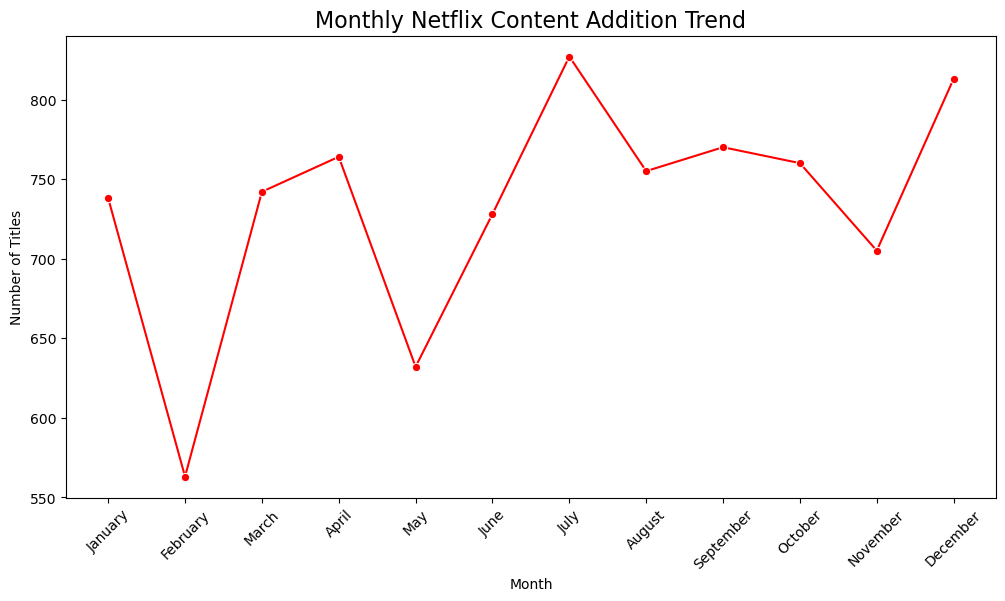

In [24]:
# Extract month name
df['month_added'] = df['date_added'].dt.month_name()

# Count monthly additions
monthly_data = df['month_added'].value_counts()

# Reorder months properly
months_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_data = monthly_data.reindex(months_order)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_data.index,
    y=monthly_data.values,
    marker='o',
    color='red'
)

# Labels
plt.title('Monthly Netflix Content Addition Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

# Netflix Ratings Distribution

This graph represents the distribution of audience ratings in Netflix content.

C:\Users\ganga\AppData\Local\Temp\ipykernel_23568\283554668.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


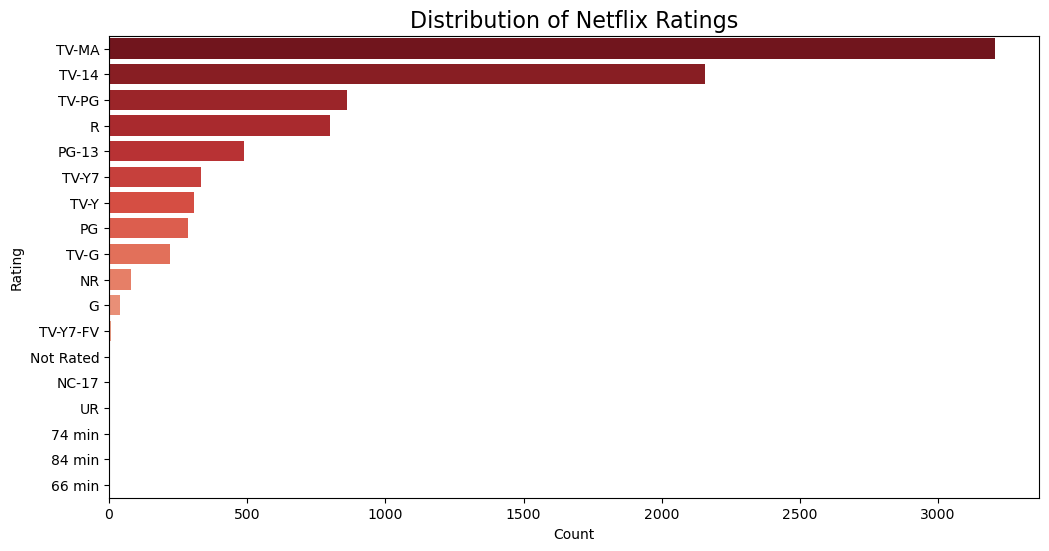

In [25]:
# Plot ratings count
plt.figure(figsize=(12,6))

sns.countplot(
    y=df['rating'],
    order=df['rating'].value_counts().index,
    palette='Reds_r'
)

# Labels
plt.title('Distribution of Netflix Ratings', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Rating')

plt.show()

# Correlation Heatmap

This heatmap represents relationships between numerical variables in the dataset.

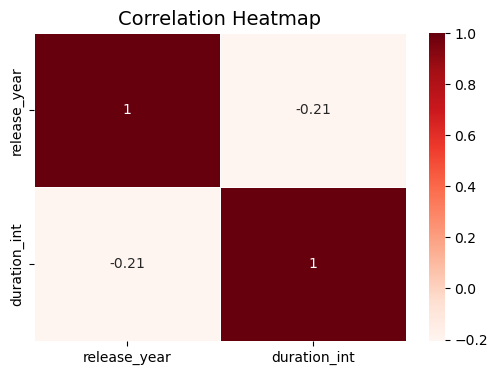

In [26]:
# Create numeric columns
numeric_df = movies_df[['release_year', 'duration_int']]

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='Reds',
    linewidths=0.5
)

# Title
plt.title('Correlation Heatmap', fontsize=14)

plt.show()